In [1]:
import os
import numpy as np
import math
import pandas as pd
from scipy.stats import multivariate_normal
from matplotlib import pyplot as plt
from tqdm import tqdm
from functools import partial
from pathos.pools import ProcessPool
import numpyro
np.random.seed(100)


# 1. Toy example: Bivariate normal

## 1. Definição de parametros

Text(0, 0.5, 'x2')

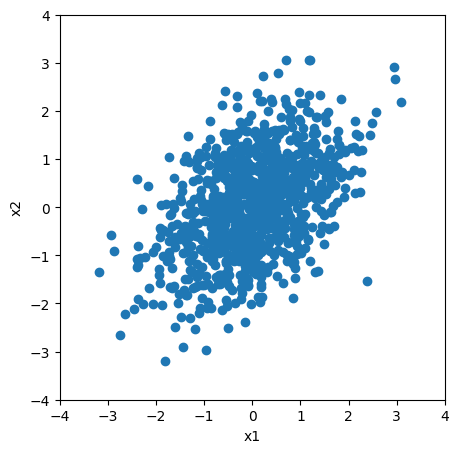

In [2]:
STARTING_DIST_LOW = -4
STARTING_DIST_HIGH = 4

# Parâmetros da normal multivariada
mu_vec = np.array([0, 0])
cov_matrix = np.array([
    [1, 0.5],
    [0.5, 1]
])

# Gerar amostras
X = np.random.default_rng().multivariate_normal(
    mean=mu_vec,
    cov=cov_matrix,
    size=1000
).T

# Plot
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(5,5)
)
ax.set_aspect('equal')
ax.scatter(
    x=X[0,:],
    y=X[1,:]
)
ax.set_xlim(STARTING_DIST_LOW,STARTING_DIST_HIGH)
ax.set_ylim(STARTING_DIST_LOW,STARTING_DIST_HIGH)
ax.set_xlabel('x1', fontsize=10)
ax.set_ylabel('x2', fontsize=10)

# 2. Inferência Bayesiana MMSE via Amostragem MCMC

##### Premissas adotadas:
##### - Vetor de médias $\mathbf{\mu}$ desconhecido, mas matriz de covariância $\mathbf{\Sigma}$ conhecida. Nestas circunstâncias, log-verossimilhança associada a conjunto de observações $\mathbf{X} = \{ \mathbf{x}_{n} \; | \; n=1,2,...,N \}$ é dada por $$ \log p(\mathbf{X}|\mathbf{\mu}) = -\frac{N}{2} \log (4 \pi^2 |\mathbf{\Sigma}| ) - \frac{1}{2} \sum_{n=0}^{N} (\mathbf{x}_{n} - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_{n} - \mathbf{\mu})^T. $$
##### - Distribuição a priori $p(\mathbf{\mu})$ uniforme no quadrado $-4 < \mu 1 < 4, \; -4 < \mu 2 < 4$.
##### - Amostragem com algoritmo Metropolis-Hastings, distribuição de proposição normal com incrementos independentes: $$ \mathbf{\mu}_{k+1} \sim N(\mathbf{\mu}_{k},\sigma_{q}^{2} \mathbf{I}) $$

In [3]:
def MH_multivariate_normal(
    X,
    sigma,
    n_samples,
    exploration_var,
    verbose,
    initial_condition
):
    def __get_log_likelihood(
        mu,
        sigma,
        X
    ):
        N = X.shape[-1]
        return (
            -(N/2)*math.log(np.linalg.det(sigma)*(2*np.pi)**2)-(1/2)*np.sum([
                ((X[:,n] - mu) @ np.linalg.inv(sigma) @ (X[:,n] - mu).T) for n in range(N)
            ])
        )
    
    def __get_log_prior(
        mu
    ):
        if (-6 < mu[0] < 6) and (-6 < mu[1] < 6):
            return math.log(1/144)
        else:
            return -np.inf
    if verbose:
        print('Condição inicial: {}'.format(initial_condition))
    mu_k = np.array(initial_condition)
    mu_samples = []
    logs = pd.DataFrame()
    iterable = tqdm(range(1, n_samples+1)) if verbose else range(1, n_samples+1)
    for k in iterable:
        # Generate new candidate sample
        mu_k_1 = mu_k + np.random.default_rng().multivariate_normal(
            mean=[0,0],
            cov=exploration_var*np.eye(2),
            size=1
        )[0]

        # Calculate log-likelihoods for current and new sample
        log_likelihood_k = __get_log_likelihood(
            mu=mu_k,
            sigma=sigma,
            X=X
        )
        log_likelihood_k_1 = __get_log_likelihood(
            mu=mu_k_1,
            sigma=sigma,
            X=X
        )

        # Calculate log priors for current and new_sample
        log_prior_k = __get_log_prior(mu_k)
        log_prior_k_1 = __get_log_prior(mu_k_1)

        # Get acceptance probability
        alpha = math.exp(
            min(
                0,
                log_likelihood_k_1 + log_prior_k_1 - log_likelihood_k - log_prior_k
            )
        )

        # Accept or not new sample
        u = np.random.default_rng().uniform()
        if u<alpha:
            accepted = 1
            log_posterior_sample = (log_likelihood_k_1 + log_prior_k_1)/n_samples
        else:
            mu_k_1 = mu_k
            accepted = 0
            log_posterior_sample = (log_likelihood_k + log_prior_k)/n_samples

        
        # Log
        mu_samples.append(mu_k_1)
        logs = pd.concat(
            [
                logs,
                pd.DataFrame(
                    index=[k-1],
                    data={
                        'k': [k],
                        'mu_k': [mu_k],
                        'mu_k_1': [mu_k_1],
                        'log_likelihood_k': [log_likelihood_k],
                        'log_likelihood_k_1': [log_likelihood_k_1],
                        'log_prior_k': [log_prior_k],
                        'log_prior_k_1': [log_prior_k_1],
                        'alpha': [alpha],
                        'accepted': [accepted],
                        'sample': [mu_k_1],
                        'log_posterior_sample': [log_posterior_sample]
                    }
                )
            ],
            axis=0
        )

        # New sample becomes current sample
        mu_k=mu_k_1
        

    return mu_samples, logs

In [4]:
def MH_multivariate_normal_concurrent_chains(
    X,
    sigma,
    n_samples,
    n_chains,
    exploration_var,
    initial_conditions,
):
    # Wrap MH function
    MH_function = partial(
        MH_multivariate_normal,
        X,
        sigma,
        n_samples,
        exploration_var,
        False
    )

    with ProcessPool(os.cpu_count()) as p:
        results = p.map(
            MH_function, 
            initial_conditions
        )

    # Create dict with samples from each chain
    mu_samples_chains = {
        k:{
            'mu_samples': r[0],
            'mu1_samples': [mu[0] for mu in r[0]],
            'mu2_samples': [mu[-1] for mu in r[0]],
        } for k, r in enumerate(results)
    } 

    # Unify logs in one dataframe
    logs_chains=pd.DataFrame()
    for k, r in enumerate(results):
        df = r[-1]
        df['chain'] = k
        logs_chains = pd.concat(
            [
                logs_chains,
                df
            ],
            axis=0
        ).reset_index(
            drop=True
        )

    return mu_samples_chains, logs_chains

In [5]:
# Number of concurrent chains
N_CHAINS=8

# Number of past steps for analysis
P=1000

# Initial condition
initial_condition = [
    np.random.default_rng().uniform(
        low=STARTING_DIST_LOW,
        high=STARTING_DIST_HIGH,
        size=(2,)
    ) for _ in range(N_CHAINS)]

# Run MH
N_SAMPLES=20000
EXPLORATION_VAR=1E-4
mu_samples_chains, logs_chains = MH_multivariate_normal_concurrent_chains(
    X=X,
    sigma=cov_matrix,
    n_samples=N_SAMPLES,
    n_chains=N_CHAINS,
    exploration_var=EXPLORATION_VAR,
    initial_conditions=initial_condition
)

### Trajetórias MCMC

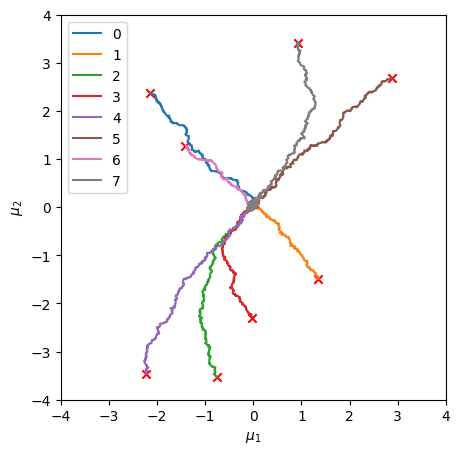

In [6]:
# Plot trajectories
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(5,5)
)
ax.set_aspect('equal')

for c in range(N_CHAINS):
    ax.scatter(
        x=initial_condition[c][0],
        y=initial_condition[c][-1],
        marker='x',
        c='red'
    )
    ax.plot(
        mu_samples_chains[c]['mu1_samples'],
        mu_samples_chains[c]['mu2_samples'],
        label=c
    )

ax.set_xlim(STARTING_DIST_LOW,STARTING_DIST_HIGH)
ax.set_ylim(STARTING_DIST_LOW,STARTING_DIST_HIGH)
ax.set_xlabel(r'$\mu_{1}$', fontsize=10)
ax.set_ylabel(r'$\mu_{2}$', fontsize=10)
l = ax.legend()

### Evolução coeficientes

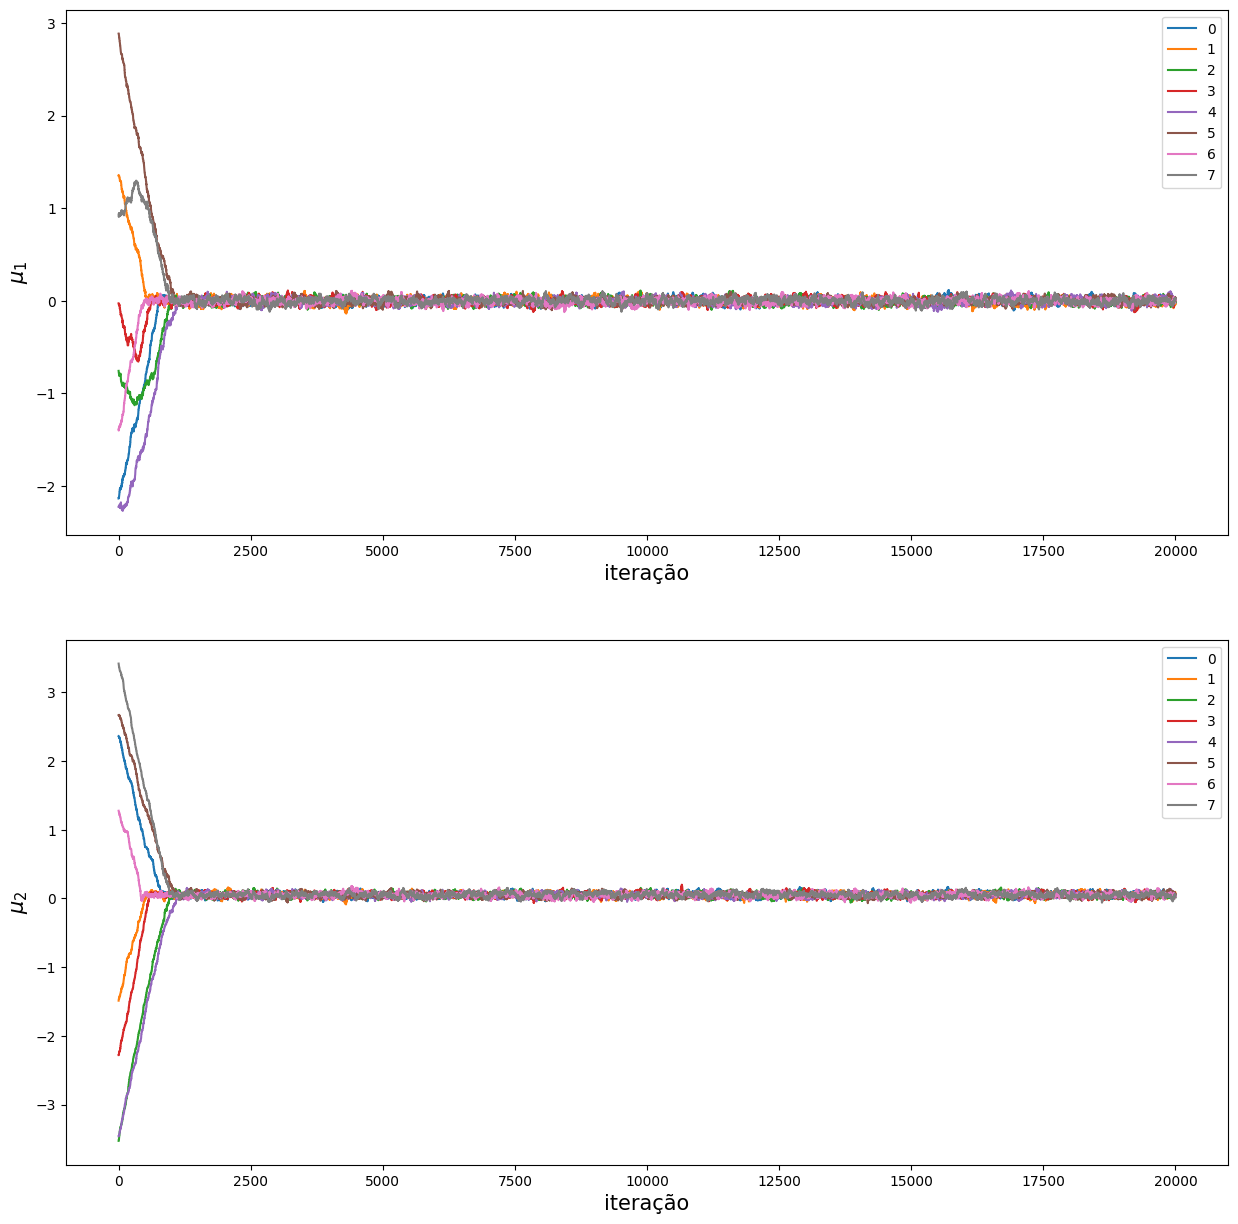

In [7]:
# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

for c in range(N_CHAINS):
    
    ax1.plot(
        mu_samples_chains[c]['mu1_samples'],
        label=c
    )
    ax2.plot(
        mu_samples_chains[c]['mu2_samples'],
        label=c
    )
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
l2 = ax2.legend()

### Evolução log-posteriori normalizada

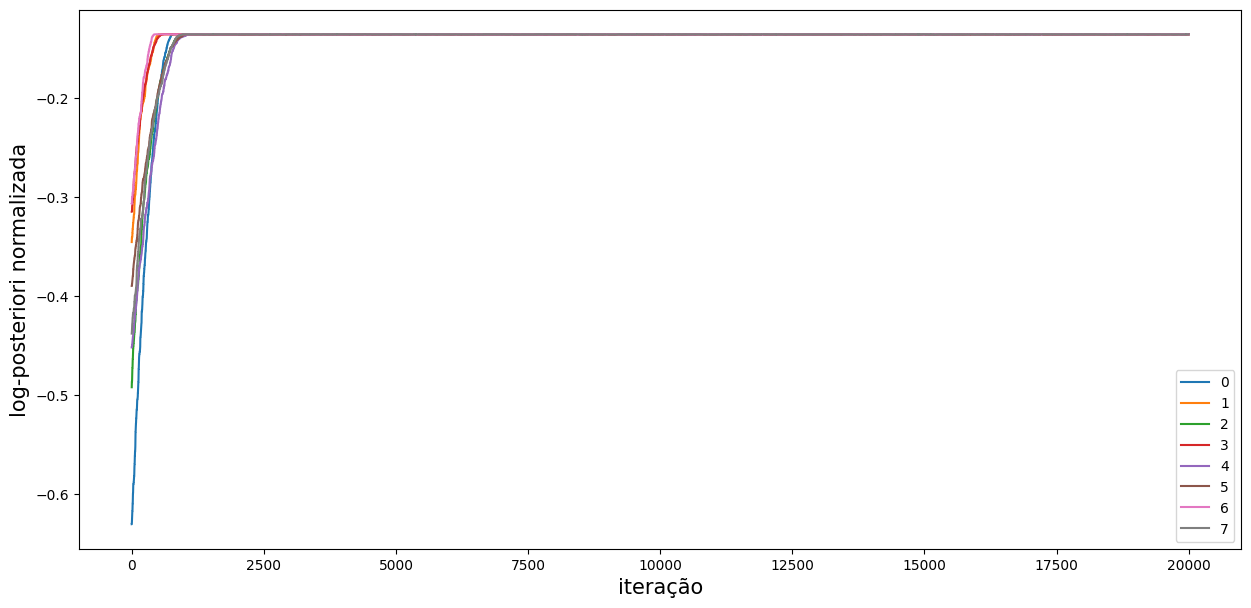

In [8]:
# Plot posteriors
fig, ax = plt.subplots(
    nrows=1,ncols=1,
    figsize=(15,7)
)

for c, group in logs_chains.groupby(by='chain'):
    ax.plot(
        group['log_posterior_sample'].values,
        label=c
    )

ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    'log-posteriori normalizada',
    fontsize=15
)
l = ax.legend()

### Média móvel: probabilidades de aceite

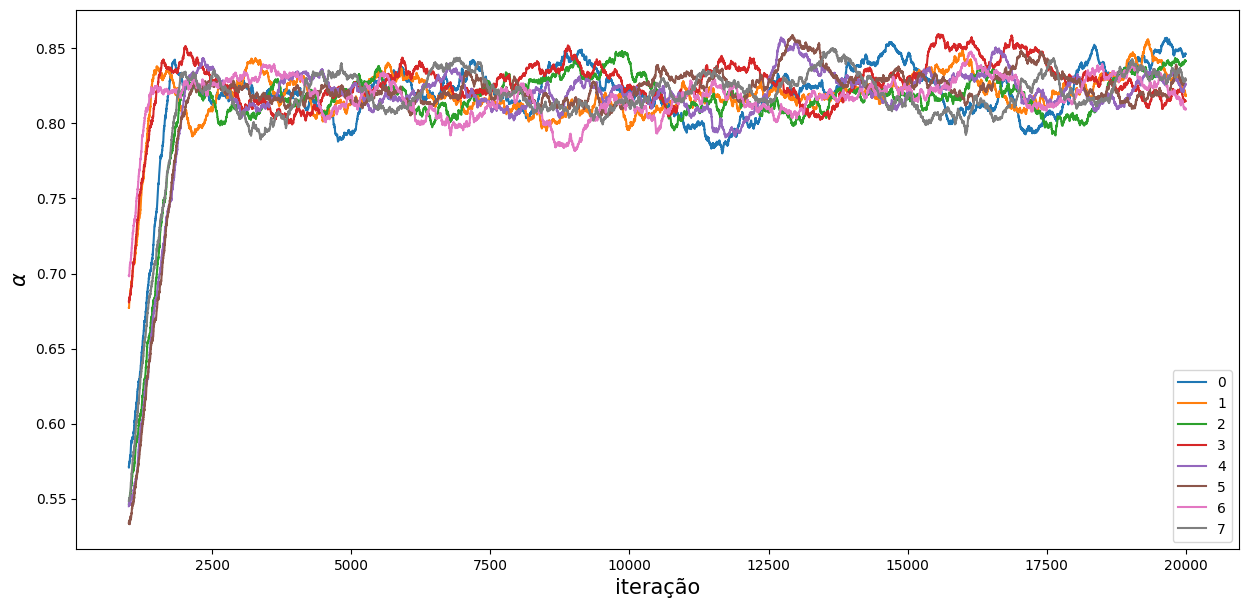

In [9]:
# Plot alpha
MA_alphas = {
    c: [
        np.mean(logs_chains[logs_chains.chain==c]['alpha'].values[k-P:k]) for k in range(P, N_SAMPLES)
    ] for c in range(N_CHAINS)
}

fig, ax = plt.subplots(
    nrows=1,ncols=1,
    figsize=(15,7)
)
for c, ma in MA_alphas.items():
    ax.plot(
        range(P,N_SAMPLES),
        ma,
        label=c
    )
ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    r'$\alpha$',
    fontsize=15
)
l = ax.legend()

### Média móvel: taxas de aceite

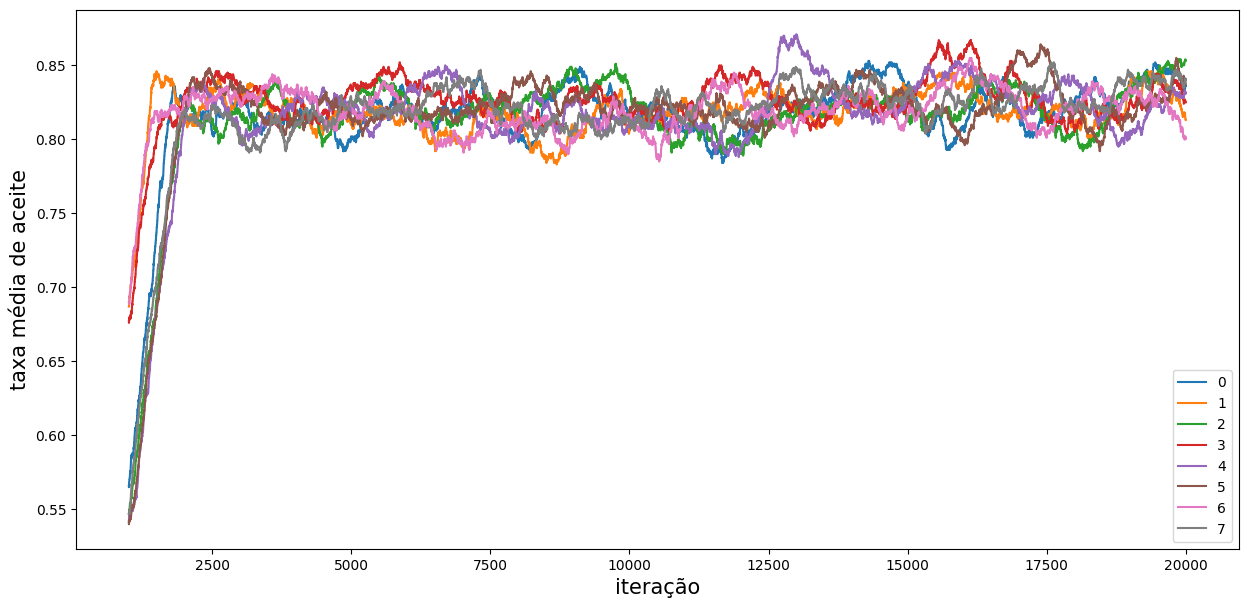

In [10]:
# Plot average acceptance rate
MA_accepted = {
    c: [
        np.mean(logs_chains[logs_chains.chain==c]['accepted'].values[k-P:k]) for k in range(P, N_SAMPLES)
    ] for c in range(N_CHAINS)
}

fig, ax = plt.subplots(
    nrows=1,ncols=1,
    figsize=(15,7)
)
for c, ma in MA_accepted.items():
    ax.plot(
        range(P,N_SAMPLES),
        ma,
        label=c
    )
ax.set_xlabel(
    'iteração',
    fontsize=15
)
ax.set_ylabel(
    r'taxa média de aceite',
    fontsize=15
)
l = ax.legend()

## 3. Potential Scale Reduction Factor ($\hat{R}$) - Gelman and Rubin, 1992 - Implementação própria

Ideia geral: 
- Utilização de estatísticas de múltiplas cadeias concorrentes, inicializadas em pontos diversos.
- Distribuição de inicialização deve ter variância superior ("overdispersed") à da função-alvo amostrada.
- Método traz uma atualização iterativa de uma estimativa da função-alvo amostrada, a qual toma a forma de uma distribuição Student-t.
- Métrica $\hat{R}$ mede o quanto se estima que a variância da distribuição t pode ainda ser reduzida, no limite, com a continuidade das iterações. Esse fator de redução de escala é a métrica utilizada para avaliar proximidade de convergência, na qual deve estar próximo de 1.

Procedimento (para cada escalar estimado):
- Simular $m \geq 2$ cadeias $x_{i}$ com inicialização independente, por um número 2n de iterações.
- Descartar n primeiras amostras, e com as últimas n calcular indicadores $B$ e $W$.
- $B/n$: variância entre as médias $\overline{x}_{i}$ das $m$ cadeias, calculadas com base em $n$ últimos valores de cada cadeia.
- $W$: média entre as variâncias $s_{i}^2$ de cada uma das $m$ cadeias. Artigo propõe que W deve ser inferior à variância da função-alvo, uma vez que as cadeias individuais ainda não tiveram tempo de explorar sobre toda esta função.

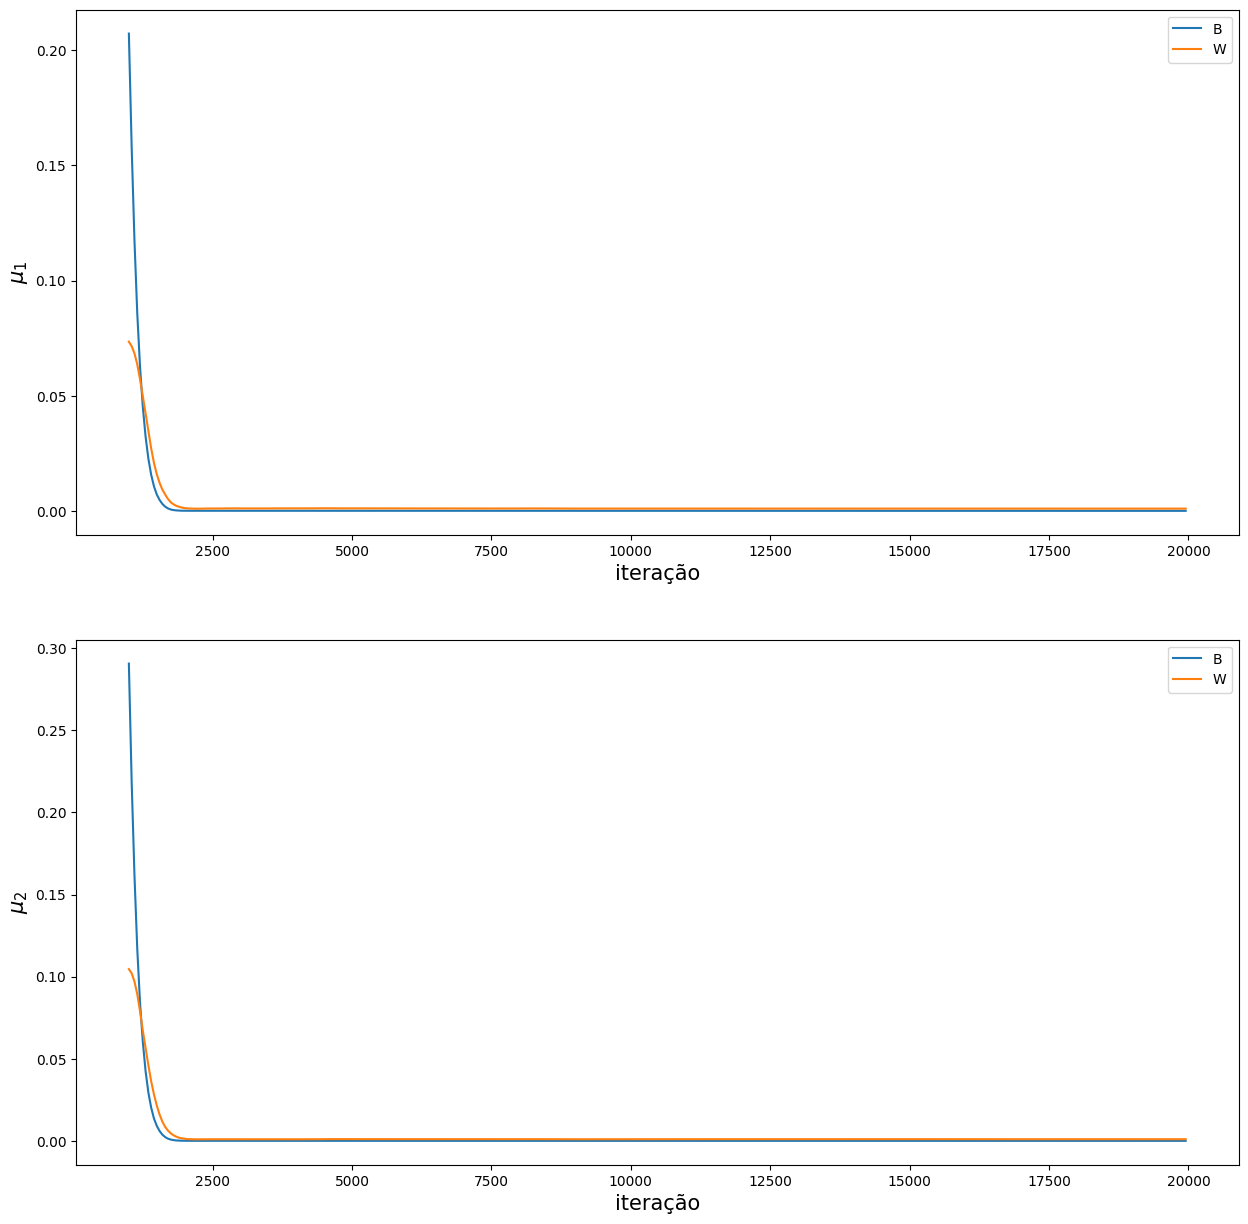

In [25]:
n_interval=50
evaluated_ns = range(1000,N_SAMPLES,n_interval)

# Variance of within-sequence means
B_mu1 = [
    np.var([
       np.mean(mu_samples_chains[c]['mu1_samples'][n//2:n]) for c in range(N_CHAINS)
    ]) for n in evaluated_ns
]
B_mu2 = [
    np.var([
       np.mean(mu_samples_chains[c]['mu2_samples'][n//2:n]) for c in range(N_CHAINS)
    ]) for n in evaluated_ns
]

# Mean of within-sequence variances
W_mu1 = [
    np.mean([
       np.var(mu_samples_chains[c]['mu1_samples'][n//2:n]) for c in range(N_CHAINS)
    ]) for n in evaluated_ns
]
W_mu2 = [
    np.mean([
       np.var(mu_samples_chains[c]['mu2_samples'][n//2:n]) for c in range(N_CHAINS)
    ]) for n in evaluated_ns
]

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

# Ax1
ax1.plot(
    evaluated_ns,
    B_mu1,
    label='B'
)
ax1.plot(
    evaluated_ns,
    W_mu1,
    label='W'
)
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

# Ax2
ax2.plot(
    evaluated_ns,
    B_mu2,
    label='B'
)
ax2.plot(
    evaluated_ns,
    W_mu2,
    label='W'
)

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
l2 = ax2.legend()


Obter estimativa $\hat{\sigma}^2$ da variância da função-alvo amostrada: $$ \hat{\sigma}^2 = \frac{n-1}{n}W + \frac{1}{n}B,$$ a qual super-estima a variância da função-alvo: distribuição inicial com dispersão superior à da função-alvo contribui para aumento no valor de B. 

A seguir, realiza-se atualização na caracterização da distribuição amostrada. Aproxima-se esta distribuição por uma distribuição Student-t com centro em $\hat{\mu}$ e variância $\hat{V}$, em que $\hat{\mu}$ é a média das $mn$ amostras consideradas nas cadeias, e $$ \hat{V} = \hat{\sigma}^2 + \frac{B}{mn}.$$ A consideração do valor de $B/mn$ se deve à inclusão da incerteza a respeito da média $\hat{\mu}$. O artigo propõe também uma relação complexa para o número de graus de liberdade $df$ da distribuição t.


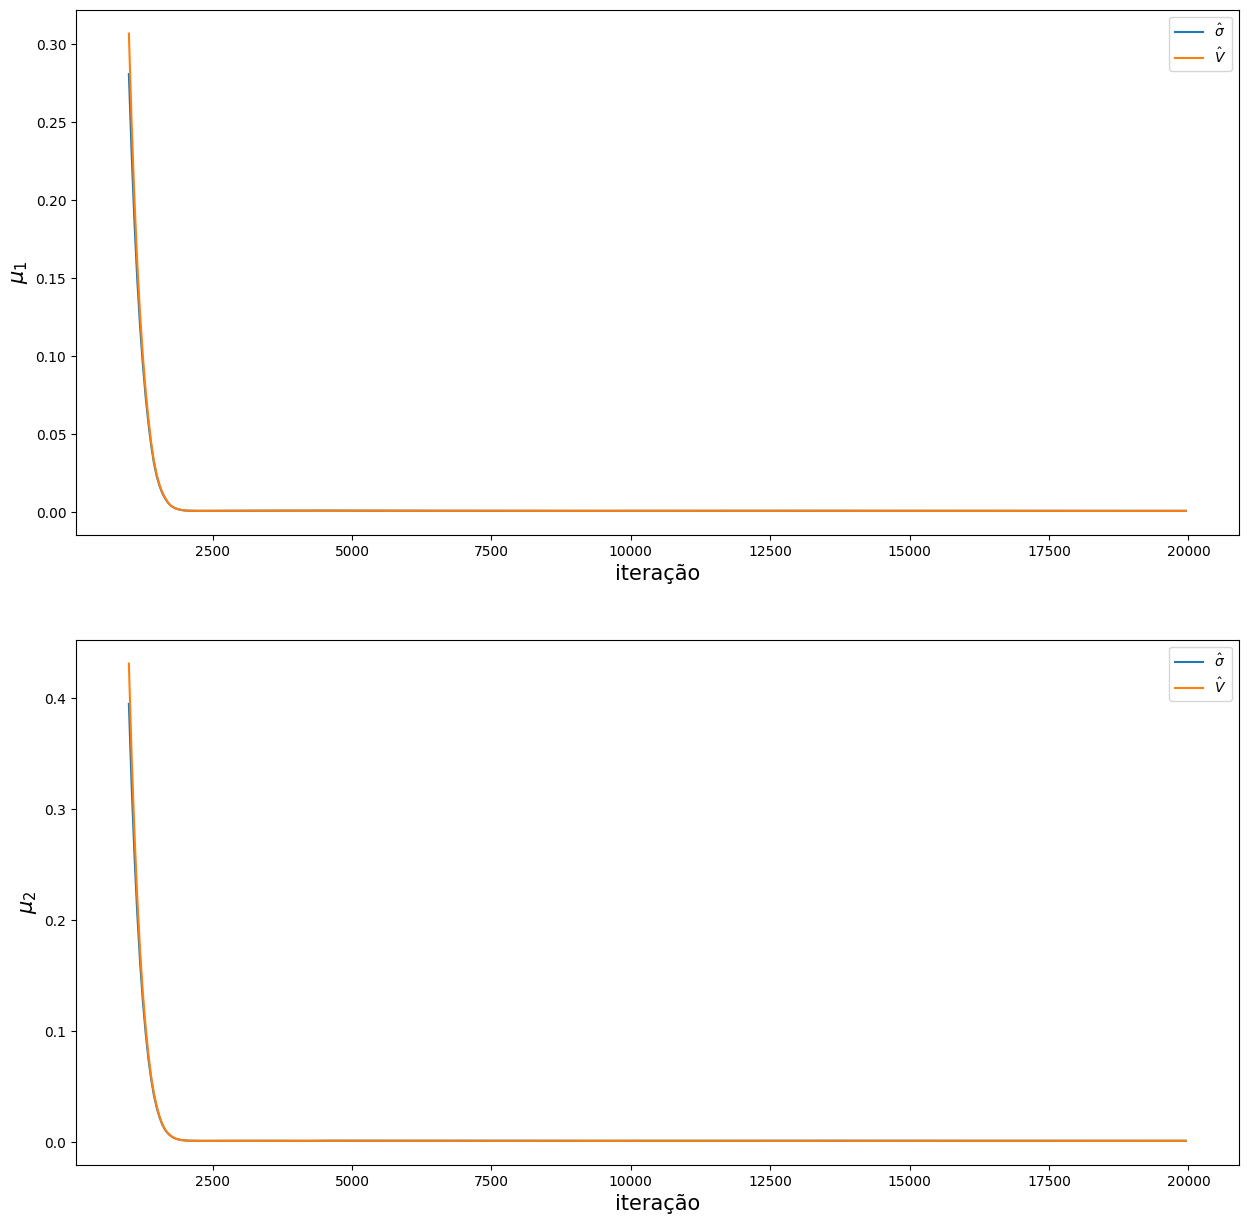

In [26]:
# Estimated target variances
sigma_est_mu1 = [
    ((n//2)-1)/(n//2)*w + b for b, w, n in zip(B_mu1, W_mu1, evaluated_ns)
]
sigma_est_mu2 = [
    (((n//2)-1)/(n//2))*w + b for b, w, n in zip(B_mu2, W_mu2, evaluated_ns)
]

# Estimated t variance
V_est_mu1 = [
    sigma + b/N_CHAINS for b, sigma, n in zip(B_mu1, sigma_est_mu1, evaluated_ns)
]
V_est_mu2 = [
    sigma + b/N_CHAINS for b, sigma, n in zip(B_mu2, sigma_est_mu2, evaluated_ns)
]

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

# Ax1
ax1.plot(
    evaluated_ns,
    sigma_est_mu1,
    label=r'$\hat{\sigma}$'
)
ax1.plot(
    evaluated_ns,
    V_est_mu1,
    label=r'$\hat{V}$'
)
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

# Ax2
ax2.plot(
    evaluated_ns,
    sigma_est_mu2,
    label=r'$\hat{\sigma}$'
)
ax2.plot(
    evaluated_ns,
    V_est_mu2,
    label=r'$\hat{V}$'
)

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
l2 = ax2.legend()

In [27]:
def get_V_variances(
    m,
    n,
    s_i,
    x_i,
    B
):
    # Calculate first term
    term_1 = (((n-1)/n)**2)*np.var(s_i)/m

    # Calculates second term
    term_2 = (((m+1)/(m*n))**2)*2*(B**2)/(m-1)

    # Calculates third term
    term_3 = 2*((m-1)*(n-1)/(m*(n**2)))*(n/m)*(np.cov(s_i, np.square(x_i))[0,1] - 2*np.mean(x_i)*np.cov(s_i, x_i)[0,1])

    return term_1 + term_2 + term_3

In [28]:
# Variances of V
var_V_mu1 = [
    get_V_variances(
        m=N_CHAINS,
        n=n//2,
        s_i=[
            np.var(mu_samples_chains[c]['mu1_samples'][n//2:n]) for c in range(N_CHAINS)
        ],
        x_i=[
            np.mean(mu_samples_chains[c]['mu1_samples'][n//2:n]) for c in range(N_CHAINS)
        ],
        B=B*(n//2)
    ) for n, B in zip(evaluated_ns, B_mu1)
]
var_V_mu2 = [
    get_V_variances(
        m=N_CHAINS,
        n=P,
        s_i=[
            np.var(mu_samples_chains[c]['mu2_samples'][n//2:n]) for c in range(N_CHAINS)
        ],
        x_i=[
            np.mean(mu_samples_chains[c]['mu2_samples'][n//2:n]) for c in range(N_CHAINS)
        ],
        B=B
    ) for n, B in zip(evaluated_ns, B_mu2)
]

# Get degrees of freedom
df_mu1 = [
    2*(v**2)/var_v for v, var_v in zip(V_est_mu1, var_V_mu1)
]
df_mu2 = [
    2*(v**2)/var_v for v, var_v in zip(V_est_mu2, var_V_mu2)
]

# R-hat
R_hat_mu1 = [
   math.sqrt((v/w)*(df/(df-2))) for v, w, df in zip(V_est_mu1, W_mu1, df_mu1)
]
R_hat_mu2 = [
   math.sqrt((v/w)*(df/(df-2))) for v, w, df in zip(V_est_mu2, W_mu2, df_mu2)
]


(np.float64(9.92617446274684), np.float64(10.88974131732248))

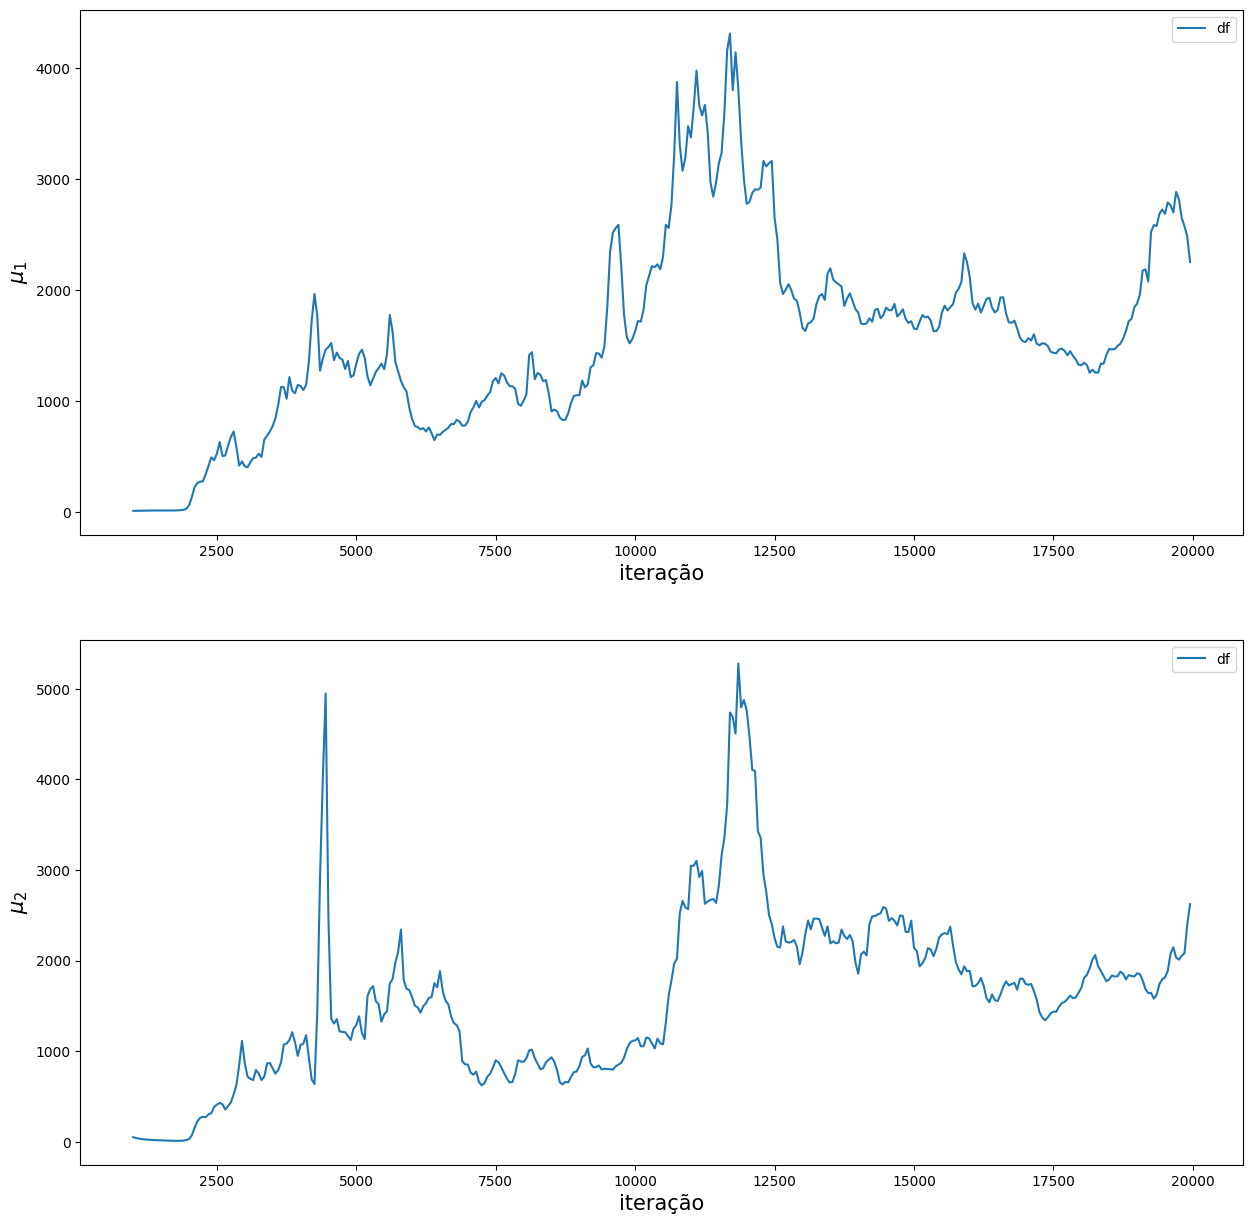

In [29]:
# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

# Ax1
ax1.plot(
    evaluated_ns,
    df_mu1,
    label=r'df'
)
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
# ax1.set_ylim(0,10)
ax1.legend()

# Ax2
ax2.plot(
    evaluated_ns,
    df_mu2,
    label=r'df'
)

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
# ax2.set_xlim(500,1000)
# ax2.set_ylim(0,10)
l2 = ax2.legend()
min(df_mu1), min(df_mu2)

A partir dos demais indicadores, é obtido o indicador $\hat{R}$ $$ \hat{R} = \frac{\hat{V}}{W} \frac{df}{df-2}, $$ o qual converge para 1 à medida que $n \rightarrow \infty$.

,n,R_hat_mu1,R_hat_mu2
0,1000,2.285726,2.071768
1,2000,1.040663,1.053319
2,3000,1.034447,1.032905
3,4000,1.017591,1.006138
4,5000,1.021404,1.019980
5,6000,1.010793,1.010628
6,7000,1.006739,1.008625
7,8000,1.007094,1.006531
8,9000,1.008988,1.003700
9,10000,1.015328,1.006780


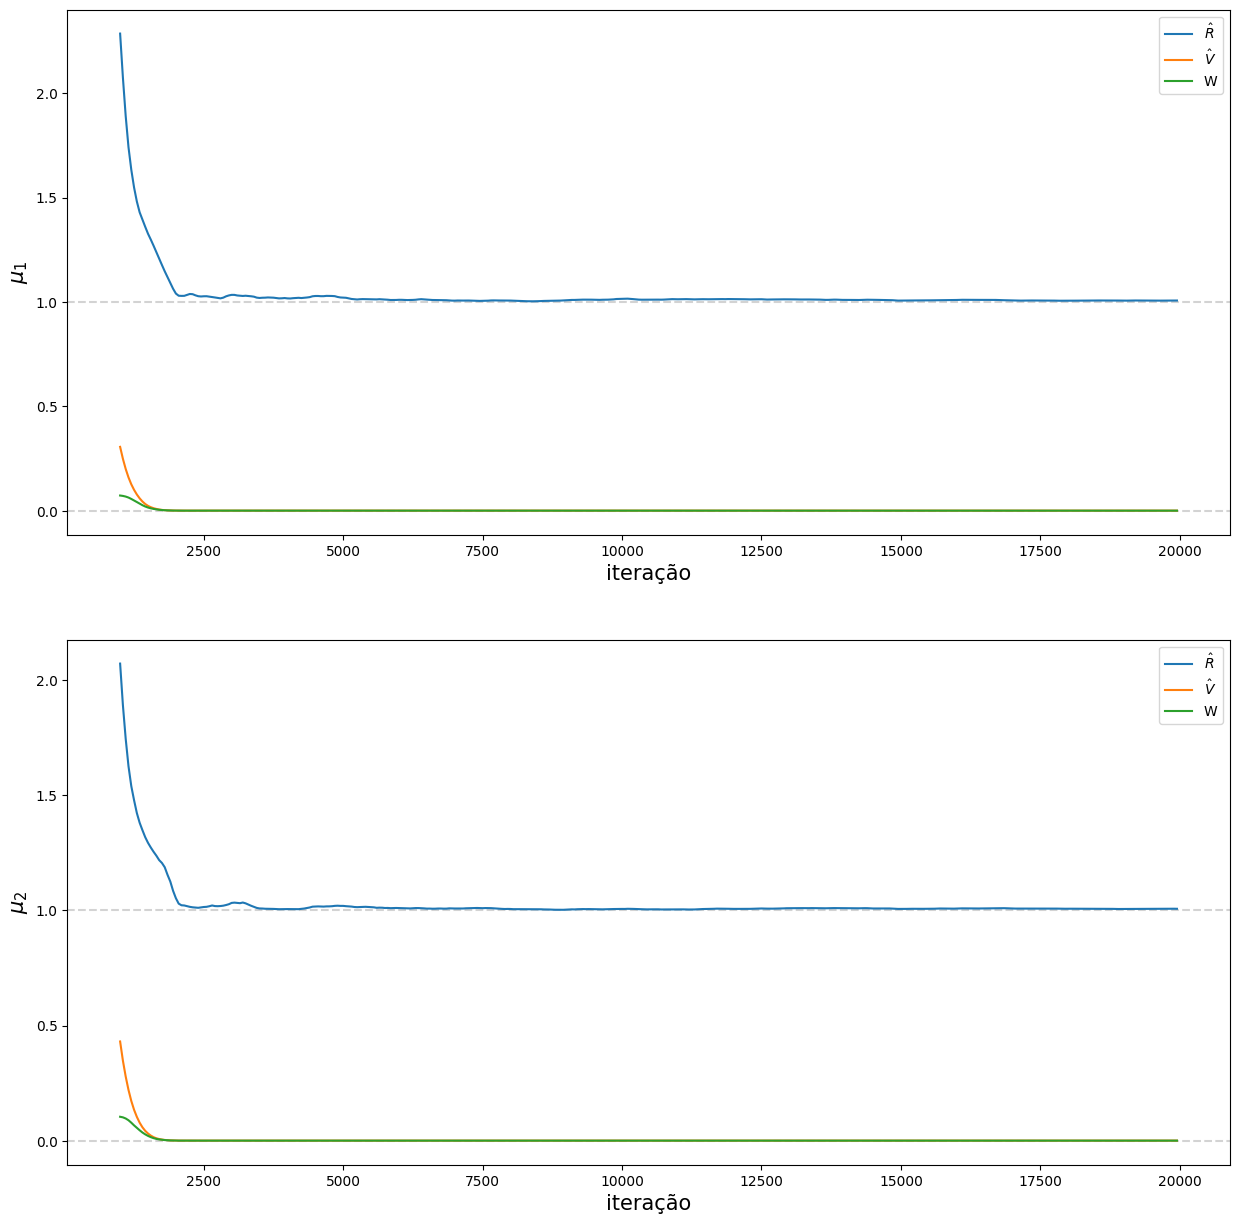

In [30]:
display_every=1000
step=display_every//n_interval

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

# Ax1
ax1.axhline(
    0,
    c='lightgray',
    ls='--'
)
ax1.axhline(
    1,
    c='lightgray',
    ls='--'
)
ax1.plot(
    evaluated_ns,
    R_hat_mu1,
    label=r'$\hat{R}$'
)
ax1.plot(
    evaluated_ns,
    V_est_mu1,
    label=r'$\hat{V}$'
)
ax1.plot(
    evaluated_ns,
    W_mu1,
    label=r'W'
)
# ax1.set_xlim(500,1000)
# ax1.set_ylim(-1,2)
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

# Ax2
ax2.axhline(
    0,
    c='lightgray',
    ls='--'
)
ax2.axhline(
    1,
    c='lightgray',
    ls='--'
)
ax2.plot(
    evaluated_ns,
    R_hat_mu2,
    label=r'$\hat{R}$'
)
ax2.plot(
    evaluated_ns,
    V_est_mu2,
    label=r'$\hat{V}$'
)
ax2.plot(
    evaluated_ns,
    W_mu2,
    label=r'W'
)

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
# ax2.set_xlim(500,1000)
# ax2.set_ylim(-1,2)
l2 = ax2.legend()


pd.DataFrame(
    data={
        'n': evaluated_ns[::step],
        'R_hat_mu1': R_hat_mu1[::step],
        'R_hat_mu2': R_hat_mu2[::step],
    }
)

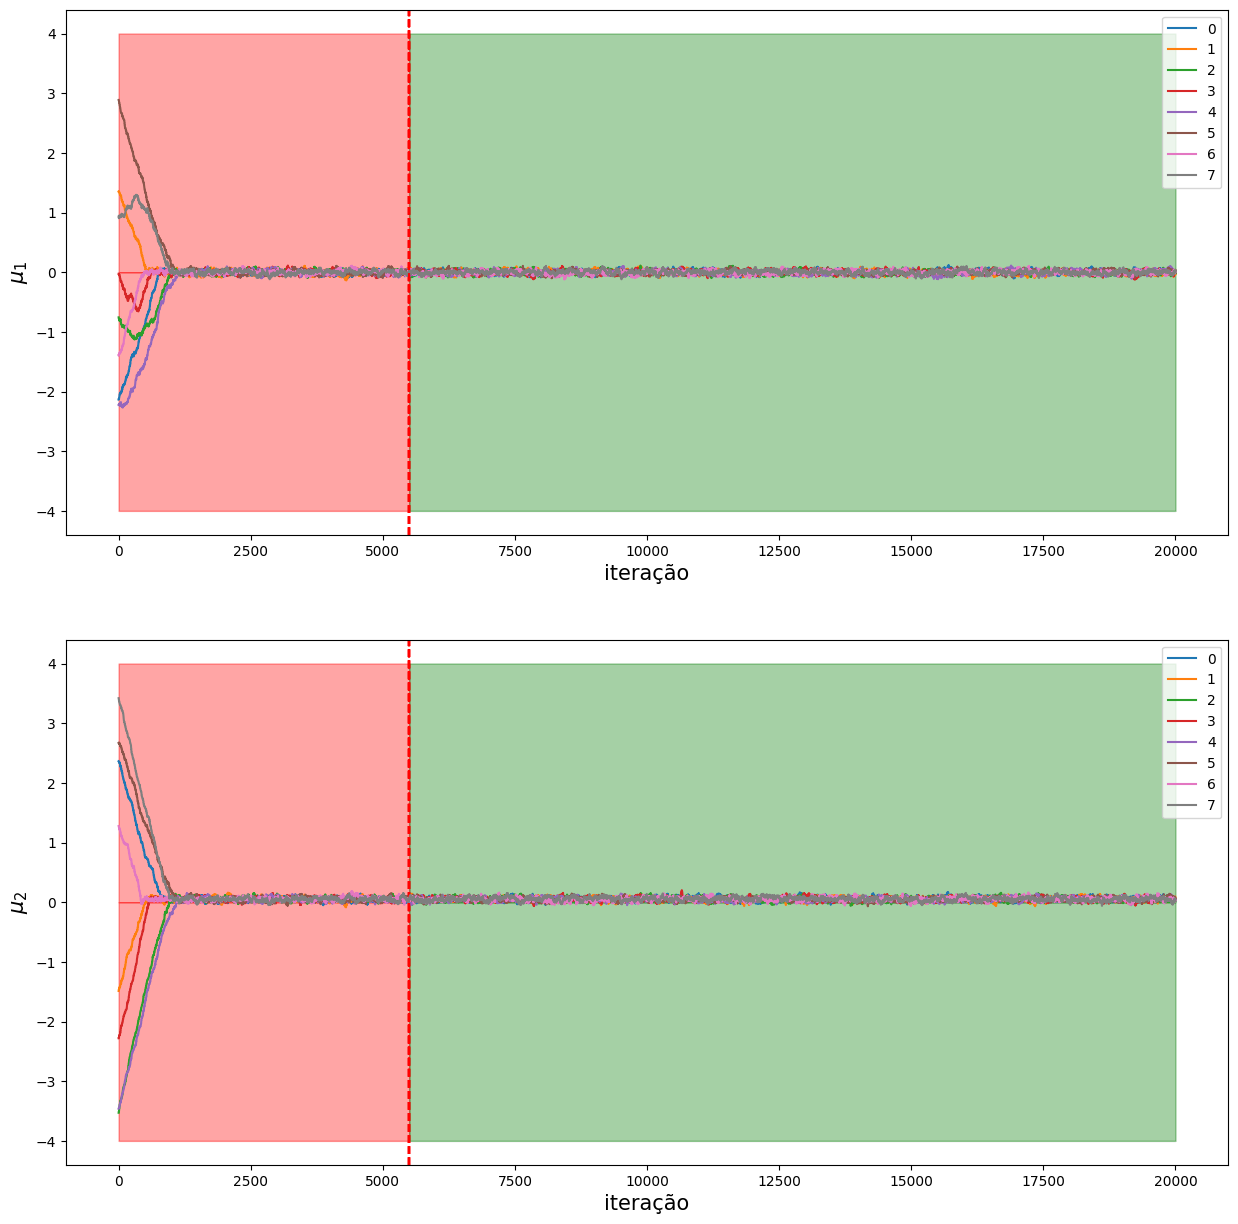

In [31]:
BURN_IN_END = 5500

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)
iterations = range(N_SAMPLES)
for c in range(N_CHAINS):
    
    #Ax1
    ax1.plot(
        iterations,
        mu_samples_chains[c]['mu1_samples'],
        label=c
    )
    for y in [STARTING_DIST_HIGH, STARTING_DIST_LOW]:
        for ax in [ax1, ax2]:
            ax.fill_between(
                range(BURN_IN_END),
                [y]*BURN_IN_END,
                color='red',
                alpha=0.05
            )
            ax.axvline(
                BURN_IN_END,
                c='red',
                linestyle='--'
            )
            ax.fill_between(
                range(BURN_IN_END,N_SAMPLES),
                [y]*(N_SAMPLES-BURN_IN_END),
                color='green',
                alpha=0.05
            )

    # Ax2
    ax2.plot(
        iterations,
        mu_samples_chains[c]['mu2_samples'],
        label=c
    )
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
l2 = ax2.legend()

In [32]:
# Join samples from chains
total_samples = []
for c, v in mu_samples_chains.items():
    total_samples = total_samples + v['mu_samples'][BURN_IN_END:]

# Obtain estimates from valid samples
mu_est = np.mean(
    np.array(total_samples),
    axis=0
)

print('Total de amostras: {}'.format(len(total_samples)))
print('Estimativa: {}'.format(mu_est))

Total de amostras: 116000
Estimativa: [-0.00117545  0.05230367]


## 4. Potential Scale Reduction Factor ($\hat{R}$) - Gelman and Rubin, 1992 - NUMPYRO

In [33]:
# Numpyro R-hat function
get_numpyro_samples = lambda samples, n, var: numpyro.diagnostics.gelman_rubin(
    x=np.array([
        v['{}_samples'.format(var)][n//2:n] for k, v in samples.items()
    ])
)

In [34]:
# Mu1 R-hats
numpyro_R_hat_mu1 = [
    get_numpyro_samples(
        samples=mu_samples_chains,
        n=n,
        var='mu1'
    ) for n in evaluated_ns
]

# Mu2 R-hats
numpyro_R_hat_mu2 = [
    get_numpyro_samples(
        samples=mu_samples_chains,
        n=n,
        var='mu2'
    ) for n in evaluated_ns
]

,n,R_hat_mu1,R_hat_mu2
0,1000,2.053239,2.041461
1,2000,1.023154,1.019474
2,3000,1.032411,1.032194
3,4000,1.016953,1.005280
4,5000,1.020959,1.019487
5,6000,1.009739,1.010153
6,7000,1.005592,1.007559
7,8000,1.006185,1.005477
8,9000,1.008157,1.002541
9,10000,1.014935,1.005973


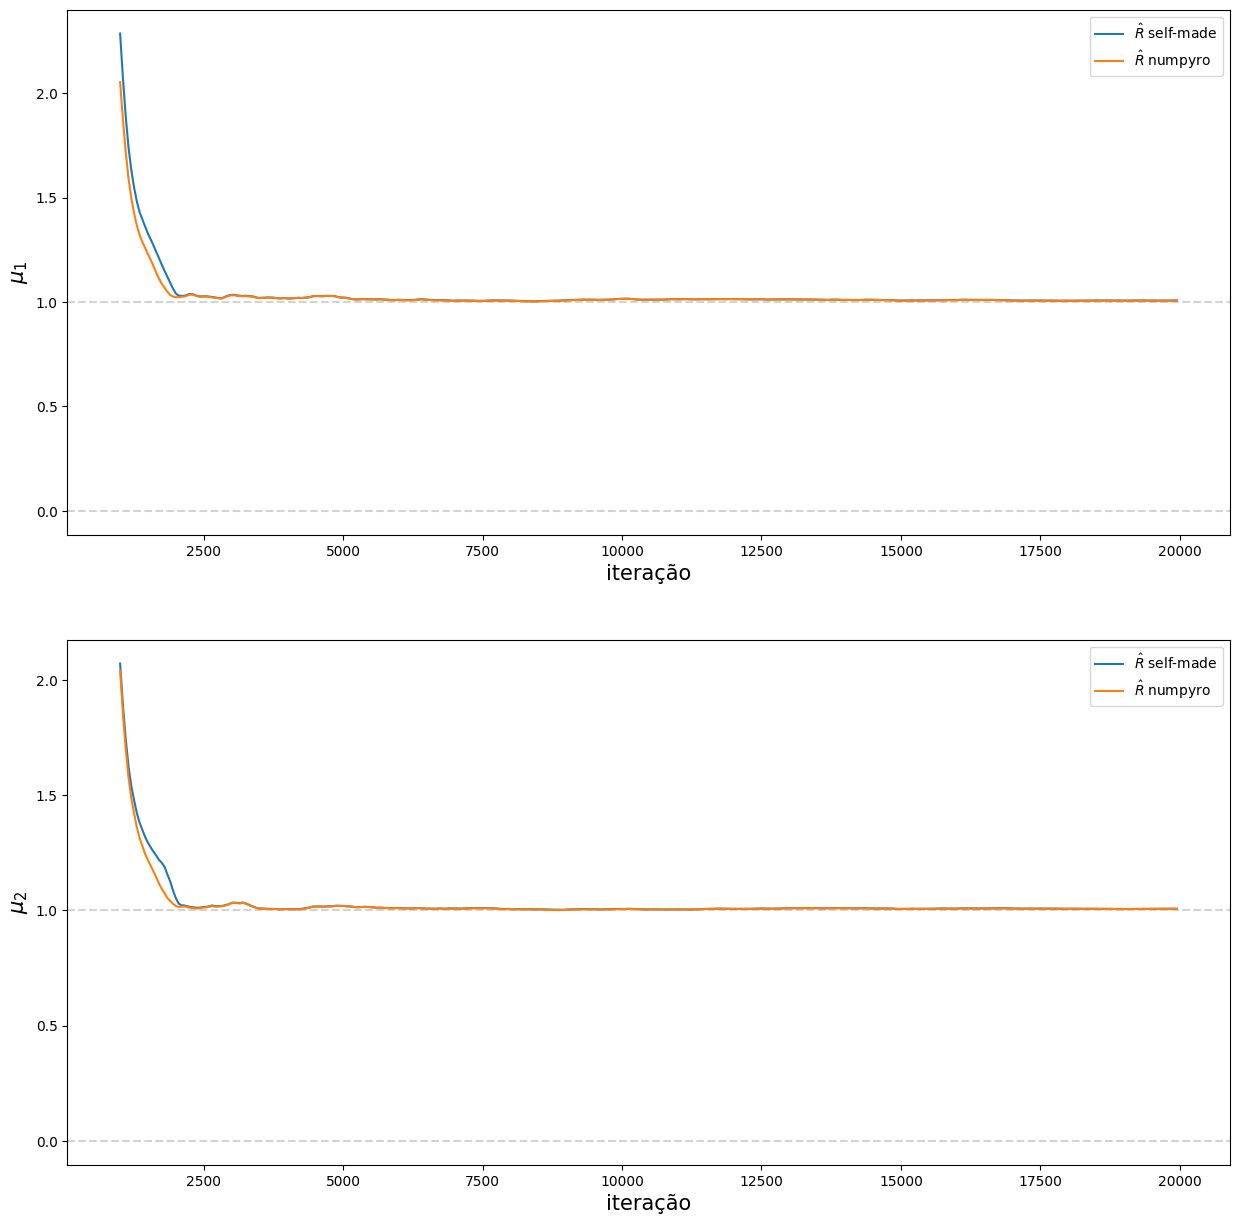

In [35]:
display_every=1000
step=display_every//n_interval

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)

# Ax1
ax1.axhline(
    0,
    c='lightgray',
    ls='--'
)
ax1.axhline(
    1,
    c='lightgray',
    ls='--'
)
ax1.plot(
    evaluated_ns,
    R_hat_mu1,
    label=r'$\hat{R} \; \text{self-made}$'
)
ax1.plot(
    evaluated_ns,
    numpyro_R_hat_mu1,
    label=r'$\hat{R} \; \text{numpyro}$'
)

ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

# Ax2
ax2.axhline(
    0,
    c='lightgray',
    ls='--'
)
ax2.axhline(
    1,
    c='lightgray',
    ls='--'
)
ax2.plot(
    evaluated_ns,
    R_hat_mu2,
    label=r'$\hat{R} \; \text{self-made}$'
)
ax2.plot(
    evaluated_ns,
    numpyro_R_hat_mu2,
    label=r'$\hat{R} \; \text{numpyro}$'
)

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
# ax2.set_xlim(500,1000)
# ax2.set_ylim(-1,2)
l2 = ax2.legend()


pd.DataFrame(
    data={
        'n': evaluated_ns[::step],
        'R_hat_mu1': numpyro_R_hat_mu1[::step],
        'R_hat_mu2': numpyro_R_hat_mu2[::step],
    }
)

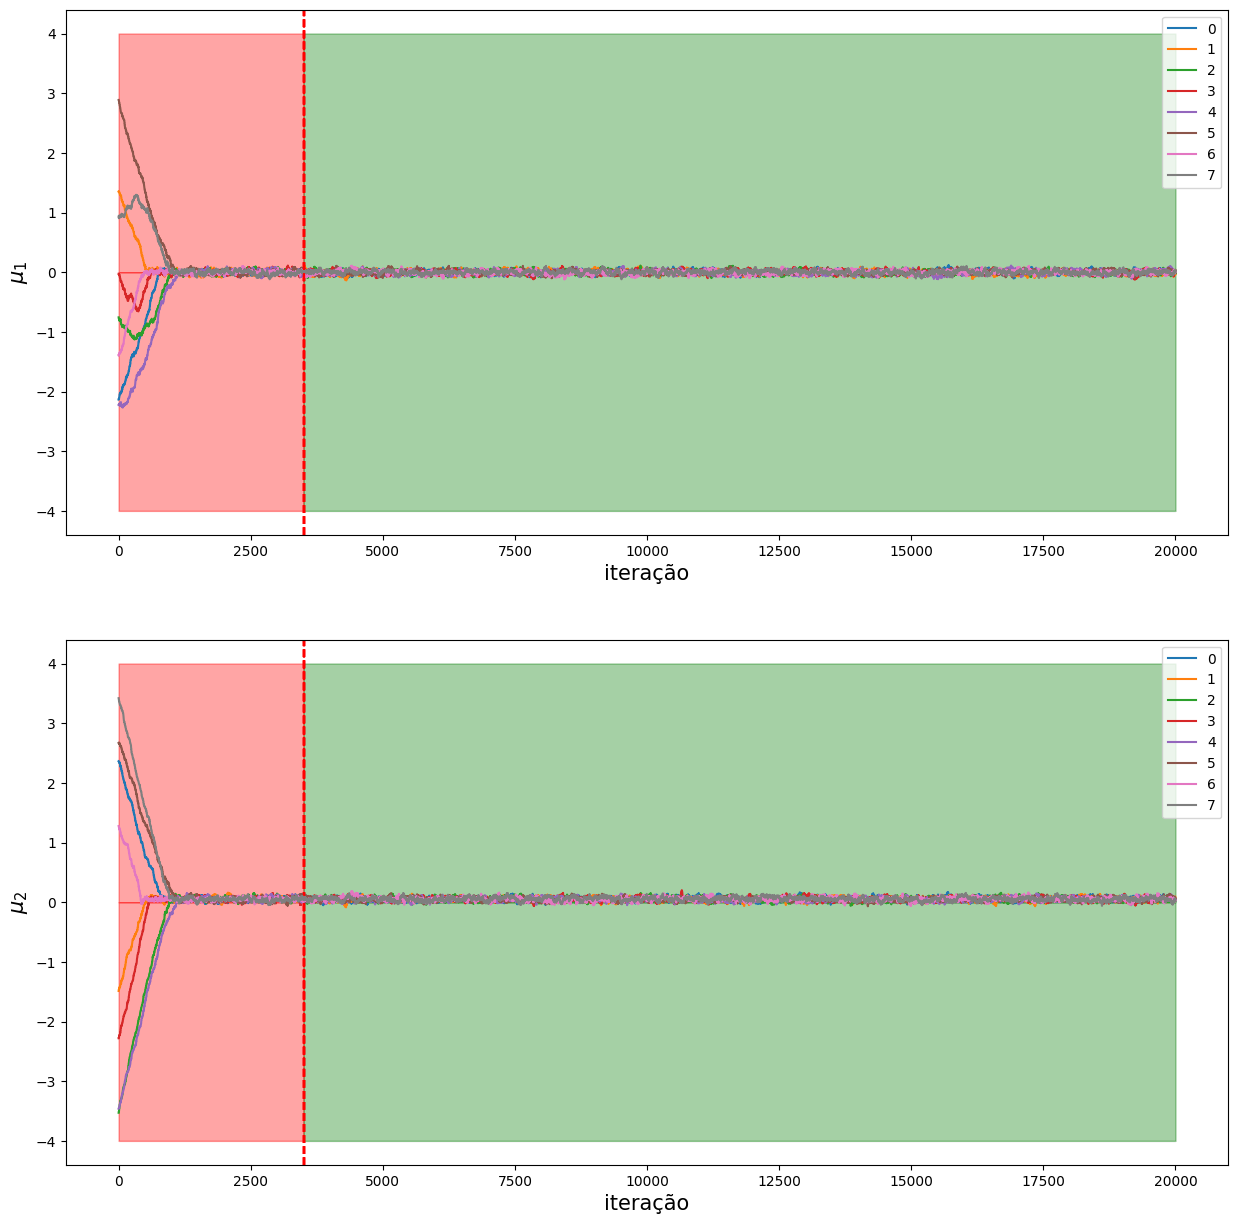

In [23]:
BURN_IN_END = 3500

# Plot evolução coeficientes
fig, (ax1, ax2) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15,15)
)
iterations = range(N_SAMPLES)
for c in range(N_CHAINS):
    
    #Ax1
    ax1.plot(
        iterations,
        mu_samples_chains[c]['mu1_samples'],
        label=c
    )
    for y in [STARTING_DIST_HIGH, STARTING_DIST_LOW]:
        for ax in [ax1, ax2]:
            ax.fill_between(
                range(BURN_IN_END),
                [y]*BURN_IN_END,
                color='red',
                alpha=0.05
            )
            ax.axvline(
                BURN_IN_END,
                c='red',
                linestyle='--'
            )
            ax.fill_between(
                range(BURN_IN_END,N_SAMPLES),
                [y]*(N_SAMPLES-BURN_IN_END),
                color='green',
                alpha=0.05
            )

    # Ax2
    ax2.plot(
        iterations,
        mu_samples_chains[c]['mu2_samples'],
        label=c
    )
    
ax1.set_xlabel(
    'iteração',
    fontsize=15
)
ax1.set_ylabel(
    r'$\mu_{1}$',
    fontsize=15
)
ax1.legend()

ax2.set_xlabel(
    'iteração',
    fontsize=15
)
ax2.set_ylabel(
    r'$\mu_{2}$',
    fontsize=15
)
l2 = ax2.legend()